# Actor-Critic Reinforcement Learning on CartPole-v1

This notebook implements the **Advantage Actor-Critic (A2C)** algorithm with PyTorch and OpenAI Gym, using the `CartPole-v1` environment. Two update schemes are compared:

- **One-step Actor-Critic** — the actor and critic networks are updated after every single environment step.
- **N-step Actor-Critic** — the networks are updated after accumulating `max_steps` transitions (or at episode end), using n-step returns.

## Contents
1. Import libraries
2. Build the actor and critic networks
3. Initialize the environment and hyperparameters
4. Train and evaluate the one-step algorithm
5. Train and evaluate the n-step algorithm

# Import Libraries

In [2]:
import gym                        # OpenAI Gym toolkit (used to build the environment)
import numpy as np                # NumPy for numerical operations and matrix handling
import torch                      # PyTorch for building and training the neural networks
from torch import nn              # Neural network module from PyTorch
import matplotlib.pyplot as plt   # Matplotlib for plotting the results

# Building the Deep Neural Networks

In [3]:
class Actor(nn.Module):                       # Defines the forward pass of the actor network
    def __init__(self, states, actions):      # Input: state space, output: action probabilities
        super().__init__()                    # The backward pass is handled during training
        self.model = nn.Sequential(
            nn.Linear(states, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, actions),
            nn.Softmax()
        )
    
    def forward(self, X):
        return self.model(X)                     

In [4]:
class Critic(nn.Module):                      # Defines the forward pass of the critic network
    def __init__(self, states):               # Input: state space, output: state value
        super().__init__()                    # The backward pass is handled during training
        self.model = nn.Sequential(
            nn.Linear(states, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, X):
        return self.model(X)

In [5]:
class Memory():
    def __init__(self):
        self.log_probs = []
        self.values = []
        self.rewards = []
        self.dones = []

    def add(self, log_prob, value, reward, done):
        self.log_probs.append(log_prob)
        self.values.append(value)
        self.rewards.append(reward)
        self.dones.append(done)
    
    def clear(self):
        self.log_probs.clear()
        self.values.clear()
        self.rewards.clear()
        self.dones.clear()  
    
    def _zip(self):
        return zip(self.log_probs,
                self.values,
                self.rewards,
                self.dones)
    
    def __iter__(self):
        for data in self._zip():
            return data
    
    def reversed(self):
        for data in list(self._zip())[::-1]:
            yield data
    
    def __len__(self):
        return len(self.rewards)
        

# Initialization

In [6]:
env = gym.make("CartPole-v1")                                  # Create the environment
actions = env.action_space.n                                   # Number of actions available in the environment
states = env.observation_space.shape[0]                        # Number of state dimensions in the environment
actor = Actor(states, actions)                                 # Instantiate the actor network for this environment
critic = Critic(states)                                        # Instantiate the critic network for this environment
adam_actor = torch.optim.Adam(actor.parameters(), lr=1e-3)     # Adam optimizer (other optimizers could be used instead)
adam_critic = torch.optim.Adam(critic.parameters(), lr=1e-3)
gamma = 0.99                                                   # Discount factor
memory = Memory()                                              # Instantiate the memory buffer
max_steps = 1                                                  # Number of steps between updates

# One-Step Actor-Critic Algorithm

In [10]:
episode_rewards = []                                    # Stores the total reward obtained in each episode
for i in range(400):                                    # Loop over the number of episodes
    done = False                                        
    total_reward = 0                                    #
    state = env.reset()                                 # Reset the environment and get the initial state


    while not done:                                     # Continue until the episode terminates
        probs = actor(torch.from_numpy(state).float())  # Get the action probabilities from the actor
        dist = torch.distributions.Categorical(probs=probs) # Convert the actor's output into a policy distribution
        action = dist.sample()                          # Sample an action from the distribution
        next_state, reward, done, info = env.step(action.detach().data.numpy()) # Take a step in the environment and get the next state, reward, and done flag
        advantage = reward + (1-done)*gamma*critic(torch.from_numpy(next_state).float())- critic(torch.from_numpy(state).float())        
                                                                                # Compute the advantage
        total_reward += reward                          # Accumulate the reward for this episode
        state = next_state
        critic_loss = advantage.pow(2).mean()           # Critic loss function
        adam_critic.zero_grad()                         
        critic_loss.backward()                          # Backpropagate to update the critic
        adam_critic.step()
        actor_loss = -dist.log_prob(action)*advantage.detach() # Actor loss function
        adam_actor.zero_grad()
        actor_loss.backward()
        adam_actor.step()
        #env.render()                        # Render the last few episodes for visualization
    print('Episode {} total rewarde is {} '.format(i,total_reward)) # Print the total reward for this episode
    episode_rewards.append(total_reward)
    env.close()

C:\Users\Nicki\anaconda3\envs\env_pytorch\lib\site-packages\torch\nn\modules\container.py:117: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


Episode 0 total rewarde is 95.0 
Episode 1 total rewarde is 105.0 
Episode 2 total rewarde is 122.0 
Episode 3 total rewarde is 97.0 
Episode 4 total rewarde is 97.0 
Episode 5 total rewarde is 113.0 
Episode 6 total rewarde is 106.0 
Episode 7 total rewarde is 62.0 
Episode 8 total rewarde is 98.0 
Episode 9 total rewarde is 106.0 
Episode 10 total rewarde is 103.0 
Episode 11 total rewarde is 108.0 
Episode 12 total rewarde is 94.0 
Episode 13 total rewarde is 96.0 
Episode 14 total rewarde is 86.0 
Episode 15 total rewarde is 96.0 
Episode 16 total rewarde is 103.0 
Episode 17 total rewarde is 92.0 
Episode 18 total rewarde is 120.0 
Episode 19 total rewarde is 112.0 
Episode 20 total rewarde is 101.0 
Episode 21 total rewarde is 96.0 
Episode 22 total rewarde is 110.0 
Episode 23 total rewarde is 100.0 
Episode 24 total rewarde is 103.0 
Episode 25 total rewarde is 88.0 
Episode 26 total rewarde is 111.0 
Episode 27 total rewarde is 107.0 
Episode 28 total rewarde is 92.0 
Episode 

Episode 233 total rewarde is 171.0 
Episode 234 total rewarde is 115.0 
Episode 235 total rewarde is 126.0 
Episode 236 total rewarde is 102.0 
Episode 237 total rewarde is 152.0 
Episode 238 total rewarde is 103.0 
Episode 239 total rewarde is 108.0 
Episode 240 total rewarde is 126.0 
Episode 241 total rewarde is 154.0 
Episode 242 total rewarde is 114.0 
Episode 243 total rewarde is 196.0 
Episode 244 total rewarde is 152.0 
Episode 245 total rewarde is 141.0 
Episode 246 total rewarde is 166.0 
Episode 247 total rewarde is 170.0 
Episode 248 total rewarde is 100.0 
Episode 249 total rewarde is 102.0 
Episode 250 total rewarde is 151.0 
Episode 251 total rewarde is 123.0 
Episode 252 total rewarde is 159.0 
Episode 253 total rewarde is 180.0 
Episode 254 total rewarde is 146.0 
Episode 255 total rewarde is 165.0 
Episode 256 total rewarde is 238.0 
Episode 257 total rewarde is 225.0 
Episode 258 total rewarde is 189.0 
Episode 259 total rewarde is 193.0 
Episode 260 total rewarde is

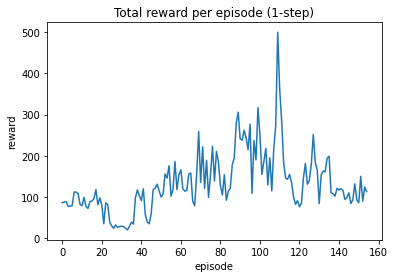

In [9]:
plt.plot(np.arange(len(episode_rewards)), episode_rewards)        # Plot total reward per episode
plt.title("Total reward per episode (1-step)")
plt.ylabel("reward")
plt.xlabel("episode")
plt.show()

# N-Step Actor-Critic Algorithm
This algorithm is very similar to the previous one, so it is not explained in detail here.

In [35]:
def train(memory, q_val):                                      # Updates the networks using the estimated value and the data stored in memory
    values = torch.stack(memory.values)
    q_vals = np.zeros((len(memory), 1))
    for i, (_, _, reward, done) in enumerate(memory.reversed()):
        q_val = reward + gamma*q_val*(1.0-done)
        q_vals[len(memory)-1 - i] = q_val        
    advantage = torch.Tensor(q_vals) - values
    critic_loss = advantage.pow(2).mean()
    adam_critic.zero_grad()
    critic_loss.backward()
    adam_critic.step()
    actor_loss = (-torch.stack(memory.log_probs)*advantage.detach()).mean()
    adam_actor.zero_grad()
    actor_loss.backward()
    adam_actor.step()

In [36]:
episode_rewards = []

for i in range(400):
    done = False
    total_reward = 0
    state = env.reset()
    steps = 0

    while not done:
        probs = actor(torch.from_numpy(state).float())
        dist = torch.distributions.Categorical(probs=probs)
        action = dist.sample()
        next_state, reward, done, info = env.step(action.detach().data.numpy())
        total_reward += reward
        steps += 1
        memory.add(dist.log_prob(action), critic(torch.from_numpy(state).float()), reward, done)  
        state = next_state
        
        if done or (steps % max_steps == 0):                                               # Update the network weights once enough steps have passed or the episode has ended
            last_q_val = critic(torch.from_numpy(next_state).float()).detach().data.numpy()
            train(memory, last_q_val)
            memory.clear()
    print('Episode {} total rewarde is {} '.format(i,total_reward))
    episode_rewards.append(total_reward)

C:\Users\Nicki\anaconda3\envs\env_pytorch\lib\site-packages\torch\nn\modules\container.py:117: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


Episode 0 total rewarde is 19.0 
Episode 1 total rewarde is 12.0 
Episode 2 total rewarde is 30.0 
Episode 3 total rewarde is 23.0 
Episode 4 total rewarde is 25.0 
Episode 5 total rewarde is 13.0 
Episode 6 total rewarde is 12.0 
Episode 7 total rewarde is 20.0 
Episode 8 total rewarde is 8.0 
Episode 9 total rewarde is 9.0 
Episode 10 total rewarde is 9.0 
Episode 11 total rewarde is 10.0 
Episode 12 total rewarde is 9.0 
Episode 13 total rewarde is 9.0 
Episode 14 total rewarde is 9.0 
Episode 15 total rewarde is 10.0 
Episode 16 total rewarde is 10.0 
Episode 17 total rewarde is 10.0 
Episode 18 total rewarde is 9.0 
Episode 19 total rewarde is 10.0 
Episode 20 total rewarde is 10.0 
Episode 21 total rewarde is 9.0 
Episode 22 total rewarde is 9.0 
Episode 23 total rewarde is 10.0 
Episode 24 total rewarde is 12.0 
Episode 25 total rewarde is 10.0 
Episode 26 total rewarde is 10.0 
Episode 27 total rewarde is 10.0 
Episode 28 total rewarde is 9.0 
Episode 29 total rewarde is 10.0 


Episode 237 total rewarde is 203.0 
Episode 238 total rewarde is 199.0 
Episode 239 total rewarde is 209.0 
Episode 240 total rewarde is 227.0 
Episode 241 total rewarde is 248.0 
Episode 242 total rewarde is 338.0 
Episode 243 total rewarde is 440.0 
Episode 244 total rewarde is 110.0 
Episode 245 total rewarde is 23.0 
Episode 246 total rewarde is 16.0 
Episode 247 total rewarde is 13.0 
Episode 248 total rewarde is 19.0 
Episode 249 total rewarde is 21.0 
Episode 250 total rewarde is 28.0 
Episode 251 total rewarde is 27.0 
Episode 252 total rewarde is 40.0 
Episode 253 total rewarde is 104.0 
Episode 254 total rewarde is 220.0 
Episode 255 total rewarde is 256.0 
Episode 256 total rewarde is 500.0 
Episode 257 total rewarde is 392.0 
Episode 258 total rewarde is 262.0 
Episode 259 total rewarde is 192.0 
Episode 260 total rewarde is 206.0 
Episode 261 total rewarde is 200.0 
Episode 262 total rewarde is 168.0 
Episode 263 total rewarde is 175.0 
Episode 264 total rewarde is 201.0 


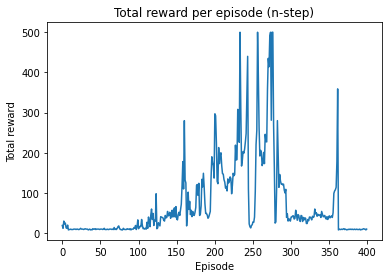

In [37]:
plt.plot(np.arange(len(episode_rewards)), episode_rewards) # Output for step size 1
plt.title("Total reward per episode (n-step)")
plt.ylabel("Total reward")
plt.xlabel("Episode")
plt.show()

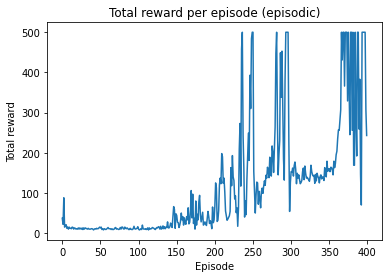

In [17]:
plt.plot(np.arange(len(episode_rewards)), episode_rewards) # Output for step size 6
plt.title("Total reward per episode (n-step)")
plt.ylabel("Total reward")
plt.xlabel("Episode")
plt.show()

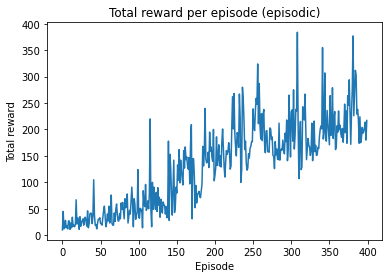

In [21]:
plt.plot(np.arange(len(episode_rewards)), episode_rewards) # Output for step size 20
plt.title("Total reward per episode (episodic)")
plt.ylabel("Total reward")
plt.xlabel("Episode")
plt.show()

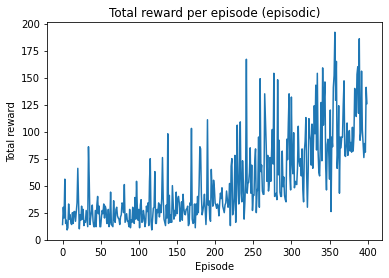

In [25]:
plt.plot(np.arange(len(episode_rewards)), episode_rewards) # Output for step size 200
plt.title("Total reward per episode (n-step)")
plt.ylabel("Total reward")
plt.xlabel("Episode")
plt.show()